# Mean Reversion Strategy Backtest

End-to-end evaluation of `compute_signals()` on historical BTC hourly data.

Reuses only `execution.kelly` and `backtest.metrics` from the main codebase — no live-bot integration.
See `BACKTEST_PLAN.md` for the cell-by-cell rationale and `../SPEC.md` for the contract.

## 1. Setup

In [ ]:
import sys
import pathlib

REPO_ROOT = pathlib.Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / 'execution').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

NOTEBOOK_DIR = REPO_ROOT / 'extensions' / 'mean_reversion'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from strategy import compute_signals
from execution.kelly import kelly_fraction, dollars_to_contracts
from backtest.metrics import compute_metrics, print_metrics

SEED = 42
np.random.seed(SEED)

print(f'repo root: {REPO_ROOT}')

## 2. Config

In [2]:
CONFIG = {
    'symbol': 'BTC-USD',
    'period': '90d',
    'interval': '1h',
    'lookback_hours': 4,
    'threshold': 0.5,
    'p_scale': 3.0,
    'starting_balance': 1000.0,
    'kelly_mult': 0.25,
    'max_position_pct': 0.05,
}

CACHE_PATH = REPO_ROOT / 'data' / 'cache' / 'btc_1h.parquet'
RESULTS_DIR = NOTEBOOK_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

# Optional: drop a pre-downloaded OHLCV CSV here to skip yfinance entirely.
# Expected columns: timestamp (UTC parseable), open, high, low, close, volume.
CSV_OVERRIDE = NOTEBOOK_DIR / 'data' / 'btc_1h.csv'

CONFIG

{'symbol': 'BTC-USD',
 'period': '90d',
 'interval': '1h',
 'lookback_hours': 4,
 'threshold': 0.5,
 'p_scale': 3.0,
 'starting_balance': 1000.0,
 'kelly_mult': 0.25,
 'max_position_pct': 0.05}

## 3. Data loading

Resolution order:
1. If `CSV_OVERRIDE` exists, load it (no network).
2. Else if `CACHE_PATH` parquet is < 24h old, load it.
3. Else fetch hourly candles from Coinbase's public `/products/{id}/candles` endpoint
   (uses `requests`, already a project dep — no extra installs).

In [ ]:
import time
import re
from datetime import datetime, timedelta, timezone

import requests

COINBASE_CANDLES_URL = 'https://api.exchange.coinbase.com/products/{product}/candles'
GRANULARITY = {'1m': 60, '5m': 300, '15m': 900, '1h': 3600, '6h': 21600, '1d': 86400}

def _normalize(df):
    df.columns = [str(c).lower() for c in df.columns]
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.set_index('timestamp')
    else:
        df.index = pd.to_datetime(df.index, utc=True)
        df.index.name = 'timestamp'
    return df[['open', 'high', 'low', 'close', 'volume']].sort_index()

def _period_to_timedelta(period):
    m = re.fullmatch(r'(\d+)([dhwmy])', period.strip().lower())
    if not m:
        raise ValueError(f'unsupported period: {period!r} (use e.g. "90d", "24h", "12w")')
    n, unit = int(m.group(1)), m.group(2)
    return timedelta(days=n * {'d': 1, 'w': 7, 'm': 30, 'y': 365}.get(unit, 0)
                     if unit != 'h' else 0,
                     hours=n if unit == 'h' else 0)

def _fetch_coinbase_candles(product, period, interval):
    if interval not in GRANULARITY:
        raise ValueError(f'unsupported interval {interval!r}; pick from {list(GRANULARITY)}')
    gran = GRANULARITY[interval]
    end = datetime.now(timezone.utc).replace(microsecond=0)
    start = end - _period_to_timedelta(period)

    # Coinbase caps each request at 300 candles. Page backwards in chunks.
    chunk = timedelta(seconds=gran * 300)
    rows = []
    cur_end = end
    while cur_end > start:
        cur_start = max(start, cur_end - chunk)
        resp = requests.get(
            COINBASE_CANDLES_URL.format(product=product),
            params={
                'granularity': gran,
                'start': cur_start.isoformat(),
                'end': cur_end.isoformat(),
            },
            timeout=15,
        )
        resp.raise_for_status()
        batch = resp.json()  # [[time, low, high, open, close, volume], ...]
        if not batch:
            break
        rows.extend(batch)
        cur_end = cur_start
        time.sleep(0.25)  # polite to the public endpoint

    if not rows:
        raise RuntimeError(f'Coinbase returned no candles for {product}')
    df = pd.DataFrame(rows, columns=['time', 'low', 'high', 'open', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['time'], unit='s', utc=True)
    df = df.drop(columns=['time']).drop_duplicates(subset='timestamp')
    return _normalize(df)

def load_ohlcv(symbol, period, interval, cache_path, csv_override, max_age_hours=24):
    if csv_override.exists():
        print(f'csv override: {csv_override}')
        return _normalize(pd.read_csv(csv_override))

    if cache_path.exists():
        age_h = (time.time() - cache_path.stat().st_mtime) / 3600
        if age_h < max_age_hours:
            print(f'cache hit ({age_h:.1f}h old): {cache_path}')
            return pd.read_parquet(cache_path)

    # Coinbase product ids use '-' (e.g. BTC-USD), same format as the configured symbol.
    df = _fetch_coinbase_candles(symbol, period, interval)
    df.to_parquet(cache_path)
    print(f'fetched {len(df)} bars from Coinbase, cached to {cache_path}')
    return df

df = load_ohlcv(
    CONFIG['symbol'], CONFIG['period'], CONFIG['interval'],
    CACHE_PATH, CSV_OVERRIDE,
)
print(f'rows: {len(df)}  range: {df.index.min()} -> {df.index.max()}')
df.head()

cache hit (0.1h old): /Users/oliver/CodeProjects/ACM AI Spring Project 2026/ACM-AI-Spring-2026-Prediction-Markets/data/cache/btc_1h.parquet


## 4. Signal generation

Calls `compute_signals` and drops the final row (its `resolved_yes` is fake — `shift(-1)` is NaN so the comparison yields 0).

signal rows: 1184
count    1.184000e+03
mean     5.031172e-01
std      4.421774e-01
min      3.025813e-08
25%      5.194322e-02
50%      8.199042e-01
75%      9.550751e-01
max      9.999993e-01
Name: p_model, dtype: float64


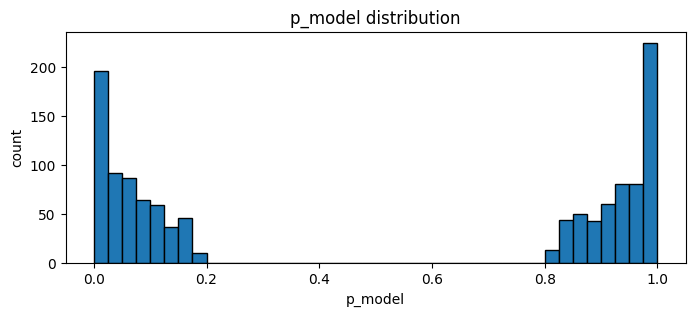

In [ ]:
signals = compute_signals(
    df,
    lookback_hours=CONFIG['lookback_hours'],
    threshold=CONFIG['threshold'],
    p_scale=CONFIG['p_scale'],
)

if len(signals) > 0 and signals.index[-1] == df.index[-1]:
    signals = signals.iloc[:-1]

print(f'signal rows: {len(signals)}')
print(signals['p_model'].describe())

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.hist(signals['p_model'], bins=40, edgecolor='black')
ax.set_title('p_model distribution')
ax.set_xlabel('p_model')
ax.set_ylabel('count')
plt.show()

## 5. Backtest loop

Canonical loop from `extensions/SPEC.md`. Sizes each bet with fractional Kelly, tracks balance and cumulative P&L.

In [ ]:
def run_backtest(signals, starting_balance, kelly_mult, max_position_pct):
    balance = starting_balance
    cumulative_pnl = 0.0
    trades = []

    for ts, row in signals.iterrows():
        bet_dollars, side = kelly_fraction(
            p_model=row['p_model'],
            market_price=row['market_price'],
            bankroll=balance,
            kelly_multiplier=kelly_mult,
            max_position_pct=max_position_pct,
        )
        if bet_dollars <= 0:
            continue

        price = row['market_price'] if side == 'YES' else (1 - row['market_price'])
        n_contracts = dollars_to_contracts(bet_dollars, price)
        if n_contracts == 0:
            continue

        cost = n_contracts * price
        won = (side == 'YES' and row['resolved_yes'] == 1) or \
              (side == 'NO' and row['resolved_yes'] == 0)
        pnl = n_contracts * (1 - price) if won else -cost
        balance += pnl
        cumulative_pnl += pnl

        trades.append({
            'timestamp': ts,
            'p_model': row['p_model'],
            'market_price': row['market_price'],
            'side': side,
            'n_contracts': n_contracts,
            'cost': round(cost, 4),
            'edge': round(abs(row['p_model'] - row['market_price']), 4),
            'resolved_yes': int(row['resolved_yes']),
            'won': won,
            'pnl': round(pnl, 4),
            'balance': round(balance, 2),
            'cumulative_pnl': round(cumulative_pnl, 4),
        })

    return pd.DataFrame(trades)

trades_df = run_backtest(
    signals,
    starting_balance=CONFIG['starting_balance'],
    kelly_mult=CONFIG['kelly_mult'],
    max_position_pct=CONFIG['max_position_pct'],
)
print(f'trades executed: {len(trades_df)}')
trades_df.head()

trades executed: 1004


,timestamp,p_model,market_price,side,n_contracts,cost,edge,resolved_yes,won,pnl,balance,cumulative_pnl
0,2026-02-14 08:00:00+00:00,0.922570,0.5,YES,100,50.0,0.4226,0,False,-50.0,950.0,-50.0
1,2026-02-14 09:00:00+00:00,0.917502,0.5,YES,95,47.5,0.4175,0,False,-47.5,902.5,-97.5
2,2026-02-14 10:00:00+00:00,0.852955,0.5,YES,90,45.0,0.3530,1,True,45.0,947.5,-52.5
3,2026-02-14 11:00:00+00:00,0.969789,0.5,YES,94,47.0,0.4698,0,False,-47.0,900.5,-99.5
4,2026-02-14 15:00:00+00:00,0.059525,0.5,NO,90,45.0,0.4405,0,True,45.0,945.5,-54.5


## 6. Metrics report

In [ ]:
if len(trades_df) == 0:
    print('no trades — strategy never produced a positive Kelly bet')
else:
    print_metrics(trades_df, starting_balance=CONFIG['starting_balance'])

    m = compute_metrics(trades_df, starting_balance=CONFIG['starting_balance'])
    sharpe = m.get('sharpe_ratio', float('nan'))
    win_rate = m.get('win_rate', float('nan'))
    max_dd = m.get('max_drawdown', float('nan'))

    print('\n--- Go / no-go ---')
    print(f'  Sharpe > 1.0     : {sharpe:.3f}   {"PASS" if sharpe > 1.0 else "FAIL"}')
    print(f'  Win rate > 52%   : {win_rate:.3f}   {"PASS" if win_rate > 0.52 else "FAIL"}')
    print(f'  Max DD > -30%    : {max_dd:.3f}   {"PASS" if max_dd > -0.30 else "FAIL"}')


  BACKTEST RESULTS
  Trades          : 1004
  Total P&L       : $-990.50
  ROI             : -99.05%
  Win Rate        : 45.9%  ⚠️
  Avg Edge        : 0.4379
  Sharpe Ratio    : -0.702  ⚠️
  Sortino Ratio   : -0.989
  Max Drawdown    : $-1443.00 (-144.3%)

  Week 6 Decision: ❌ Stay in dry-run — review strategy


--- Go / no-go ---
  Sharpe > 1.0     : -0.702   FAIL
  Win rate > 52%   : 0.459   FAIL
  Max DD > -30%    : -1443.000   FAIL


## 7. Visualizations

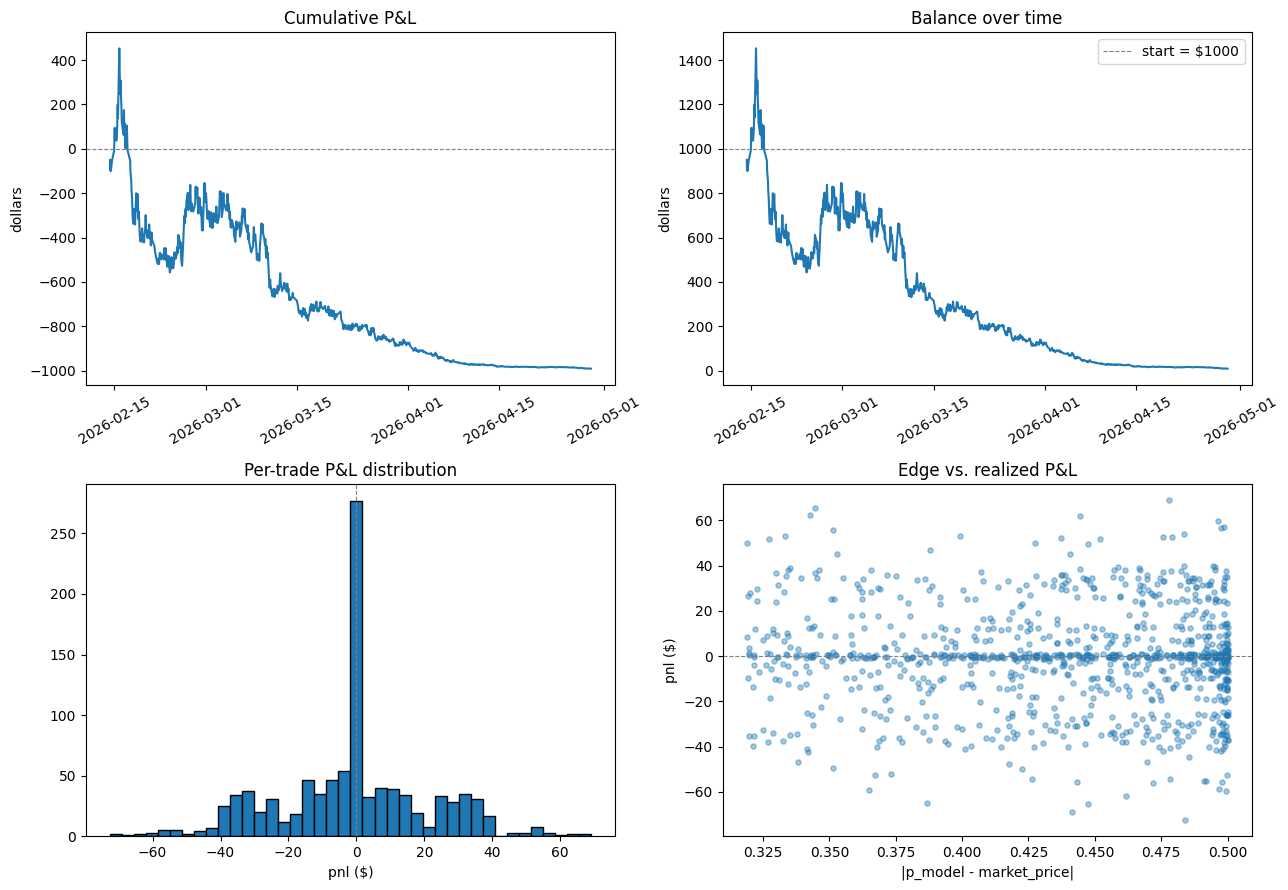

In [ ]:
if len(trades_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    ax = axes[0, 0]
    ax.plot(trades_df['timestamp'], trades_df['cumulative_pnl'])
    ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
    ax.set_title('Cumulative P&L')
    ax.set_ylabel('dollars')
    ax.tick_params(axis='x', rotation=30)

    ax = axes[0, 1]
    ax.plot(trades_df['timestamp'], trades_df['balance'])
    ax.axhline(CONFIG['starting_balance'], linestyle='--', linewidth=0.8, color='gray',
               label=f"start = ${CONFIG['starting_balance']:.0f}")
    ax.set_title('Balance over time')
    ax.set_ylabel('dollars')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

    ax = axes[1, 0]
    ax.hist(trades_df['pnl'], bins=40, edgecolor='black')
    ax.axvline(0, linestyle='--', linewidth=0.8, color='gray')
    ax.set_title('Per-trade P&L distribution')
    ax.set_xlabel('pnl ($)')

    ax = axes[1, 1]
    ax.scatter(trades_df['edge'], trades_df['pnl'], alpha=0.4, s=14)
    ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
    ax.set_title('Edge vs. realized P&L')
    ax.set_xlabel('|p_model - market_price|')
    ax.set_ylabel('pnl ($)')

    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'backtest_overview.png', dpi=120)
    plt.show()

## 8. Parameter sweep (stretch)

Grid over `(lookback_hours, threshold, p_scale)`. Reports trades, Sharpe, win rate, max drawdown for each combo.

In [ ]:
from itertools import product

GRID = {
    'lookback_hours': [1, 2, 4, 8, 24],
    'threshold': [0.0, 0.5, 1.0, 1.5],
    'p_scale': [1.0, 2.0, 3.0, 5.0],
}

sweep_rows = []
for lh, th, ps in product(GRID['lookback_hours'], GRID['threshold'], GRID['p_scale']):
    sig = compute_signals(df, lookback_hours=lh, threshold=th, p_scale=ps)
    if len(sig) > 0 and sig.index[-1] == df.index[-1]:
        sig = sig.iloc[:-1]
    td = run_backtest(
        sig,
        starting_balance=CONFIG['starting_balance'],
        kelly_mult=CONFIG['kelly_mult'],
        max_position_pct=CONFIG['max_position_pct'],
    )
    if len(td) == 0:
        sweep_rows.append({'lookback_hours': lh, 'threshold': th, 'p_scale': ps,
                           'trades': 0, 'sharpe': np.nan, 'win_rate': np.nan,
                           'max_dd': np.nan, 'final_pnl': 0.0})
        continue
    m = compute_metrics(td, starting_balance=CONFIG['starting_balance'])
    sweep_rows.append({
        'lookback_hours': lh,
        'threshold': th,
        'p_scale': ps,
        'trades': len(td),
        'sharpe': m.get('sharpe_ratio', np.nan),
        'win_rate': m.get('win_rate', np.nan),
        'max_dd': m.get('max_drawdown', np.nan),
        'final_pnl': td['cumulative_pnl'].iloc[-1],
    })

sweep_df = pd.DataFrame(sweep_rows).sort_values('sharpe', ascending=False)
sweep_df.head(15)

,lookback_hours,threshold,p_scale,trades,sharpe,win_rate,max_dd,final_pnl
64,24,0.0,1.0,2067,-0.218,0.4969,-1638.5,-913.5
65,24,0.0,2.0,2071,-0.249,0.4969,-1650.5,-942.5
66,24,0.0,3.0,2074,-0.263,0.4966,-1583.0,-955.0
67,24,0.0,5.0,2079,-0.267,0.4964,-1573.0,-957.0
68,24,0.5,1.0,1620,-0.351,0.4957,-1321.5,-929.5
69,24,0.5,2.0,1620,-0.351,0.4957,-1321.5,-929.5
70,24,0.5,3.0,1620,-0.351,0.4957,-1321.5,-929.5
71,24,0.5,5.0,1620,-0.351,0.4957,-1321.5,-929.5
73,24,1.0,2.0,1095,-0.477,0.4904,-1242.5,-905.0
72,24,1.0,1.0,1095,-0.477,0.4904,-1242.5,-905.0


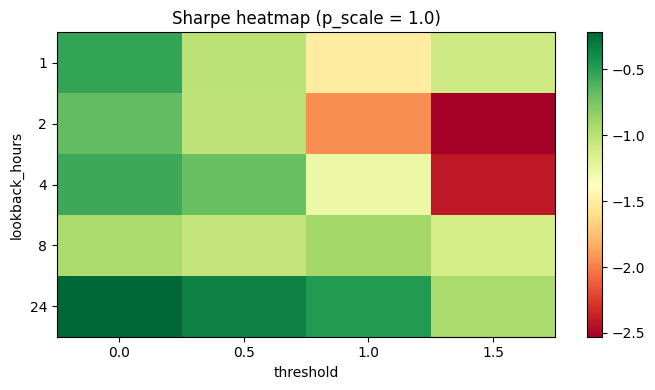

In [ ]:
if sweep_df['sharpe'].notna().any():
    best_p_scale = sweep_df.dropna(subset=['sharpe']).iloc[0]['p_scale']
    sub = sweep_df[sweep_df['p_scale'] == best_p_scale]
    heat = sub.pivot(index='lookback_hours', columns='threshold', values='sharpe')

    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel('threshold')
    ax.set_ylabel('lookback_hours')
    ax.set_title(f'Sharpe heatmap (p_scale = {best_p_scale})')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 9. Mean-reversion vs. momentum

Same config, two directions. `compute_signals` produces the mean-reversion p_model; flipping `p_model -> 1 - p_model` converts to momentum (ride the move).

In [ ]:
sig_rev = compute_signals(
    df,
    lookback_hours=CONFIG['lookback_hours'],
    threshold=CONFIG['threshold'],
    p_scale=CONFIG['p_scale'],
)
if len(sig_rev) > 0 and sig_rev.index[-1] == df.index[-1]:
    sig_rev = sig_rev.iloc[:-1]

sig_mom = sig_rev.copy()
sig_mom['p_model'] = 1.0 - sig_mom['p_model']

td_rev = run_backtest(sig_rev, CONFIG['starting_balance'], CONFIG['kelly_mult'], CONFIG['max_position_pct'])
td_mom = run_backtest(sig_mom, CONFIG['starting_balance'], CONFIG['kelly_mult'], CONFIG['max_position_pct'])

fig, ax = plt.subplots(figsize=(10, 4))
if len(td_rev) > 0:
    ax.plot(td_rev['timestamp'], td_rev['cumulative_pnl'], label='mean-reversion')
if len(td_mom) > 0:
    ax.plot(td_mom['timestamp'], td_mom['cumulative_pnl'], label='momentum')
ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
ax.set_title('Cumulative P&L — mean-reversion vs. momentum')
ax.set_ylabel('dollars')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'reversion_vs_mom.png', dpi=120)
plt.show()

def _summary(td, label):
    if len(td) == 0:
        return {'variant': label, 'trades': 0}
    m = compute_metrics(td, starting_balance=CONFIG['starting_balance'])
    return {
        'variant': label,
        'trades': len(td),
        'sharpe': m.get('sharpe_ratio', np.nan),
        'win_rate': m.get('win_rate', np.nan),
        'max_dd': m.get('max_drawdown', np.nan),
        'final_pnl': td['cumulative_pnl'].iloc[-1],
    }

pd.DataFrame([_summary(td_rev, 'mean-reversion'), _summary(td_mom, 'momentum')])

## 10. Save artifacts

In [ ]:
if len(trades_df) > 0:
    trades_path = RESULTS_DIR / 'trades.csv'
    trades_df.to_csv(trades_path, index=False)
    print(f'wrote {trades_path}')

sweep_path = RESULTS_DIR / 'param_sweep.csv'
sweep_df.to_csv(sweep_path, index=False)
print(f'wrote {sweep_path}')

wrote /Users/oliver/CodeProjects/ACM AI Spring Project 2026/ACM-AI-Spring-2026-Prediction-Markets/extensions/momentum/results/trades.csv
wrote /Users/oliver/CodeProjects/ACM AI Spring Project 2026/ACM-AI-Spring-2026-Prediction-Markets/extensions/momentum/results/param_sweep.csv
